# 2020 腾讯广告算法大赛

> 参赛者 景健 1228672201@qq.com

## 赛题:

“广告受众基础属性预估”

大多数验证所采用的方式都是以人口统计学属性作为输入来产生推荐结果，然后离线或者在线地对比用与不用这些输入的情况下的推荐性能。本届大赛的题目尝试从另一个方向来验证这个假设，即以用户在广告系统中的交互行为作为输入来预测用户的人口统计学属性。

逆向思维,通过行为来猜测用户年龄

## 数据概述


一组用户在长度为 91 天（3 个月）的时间窗口内的广告点击历史记录作为训练数据集。


每条记录中包含了日期:
- （从 1 到 91）、用户信息（年龄，性别）
- 被点击的广告的信息（素材 id、广告 id、产品 id、产品类目 id、广告主id、广告主行业 id **等**）
- 该用户当天点击该广告的次数。

## 数据说明

训练数据中包含三张表:
- click_log.csv 
    - time: 天粒度的时间，整数值，取值范围\[1, 91\]。
    - user_id: 从 1 到 N 随机编号生成的不重复的加密的用户 id，其中 N 为用户总数目（训练集和测试集）。
    - creative_id: 用户点击的广告素材的 id，采用类似于 user_id 的方式生成。
    - click_times: 当天该用户点击该广告素材的次数。
     
- user.csv
    - user_id
    - age: 分段表示的用户年龄，取值范围[1-10]。
    - gender：用户性别，取值范围[1,2]。

- ad.csv
    - creative_id
    - ad_id: 该素材所归属的广告的 id，采用类似于 user_id 的方式生成。每个广告可能包含多个可展示的素材。
    - product_id: 该广告中所宣传的产品的 id，采用类似于 user_id 的方式生成。
    - product_category: 该广告中所宣传的产品的类别 id，采用类似于 user_id 的方式生成。
    - advertiser_id: 广告主的 id，采用类似于 user_id 的方式生成。
    - industry: 广告主所属行业的 id，采用类似于 user_id 的方式生成。

## 提交说明

submission.csv 

- user_id
- predicted_age: 预测的用户年龄分段，取值范围\[1,10\]。
- predicted_gender: 预测的用户性别，取值范围\[1,2\]。


## 数据载入

In [1]:
import pandas as pd 
from pandas import DataFrame
import matplotlib.pyplot as plt
%matplotlib inline
click_log = pd.read_csv("train_preliminary/train_preliminary/click_log.csv")
ad = pd.read_csv("train_preliminary/train_preliminary/ad.csv")
user = pd.read_csv("train_preliminary/train_preliminary/user.csv")

In [4]:
click_log

,time,user_id,creative_id,click_times
0,9,30920,567330,1
1,65,30920,3072255,1
2,56,30920,2361327,1
3,6,309204,325532,1
4,59,309204,2746730,1
...,...,...,...,...
30082766,6,30920,228129,1
30082767,57,30920,2361397,1
30082768,26,30920,629802,1
30082769,86,30920,2713031,1


In [3]:
ad

,creative_id,ad_id,product_id,product_category,advertiser_id,industry
0,1,1,\N,5,381,78
1,4,4,\N,5,108,202
2,7,7,\N,5,148,297
3,8,8,\N,5,713,213
4,9,9,\N,5,695,213
...,...,...,...,...,...,...
2481130,4445714,3812196,9152,3,56976,248
2481131,4445715,3812197,39063,17,427,\N
2481132,4445716,3812198,39063,17,427,\N
2481133,4445717,3812199,35885,17,427,\N


In [5]:
user

,user_id,age,gender
0,1,4,1
1,2,10,1
2,3,7,2
3,4,5,1
4,5,4,1
...,...,...,...
899995,899996,5,1
899996,899997,3,2
899997,899998,4,2
899998,899999,3,1


## 数据挖掘与分析

行动或行为是一切的根本,即`用户`在`某一天`点击了`几次`的`某广告`

对于用户来说,我们关心他的`性别`与`年龄`信息

对于广告来说,我们关心其中的`素材`,`广告`,`产品`,`产品类目`,`广告主`,`广告主所属行业`

基本假设便是,用户和广告之间存在一些相关性:

对于用户来说,不同`性别`和`年龄`的用户会观看不同类别的广告

对于广告来说,不同类型的广告目标在于吸引不同类别的客户


## 统计函数

- freq_count

In [255]:
def freq_count(x):
    unique, counts = np.unique(x, return_counts=True)
    return np.asarray((unique, counts)).T

### 用户统计分析

- 获得用户年龄段分布
- 获得用户性别分布
- 获得用户年龄段与性别联合分布

目标结果并作图

array([<matplotlib.axes._subplots.AxesSubplot object at 0x000001F678745248>],
      dtype=object)

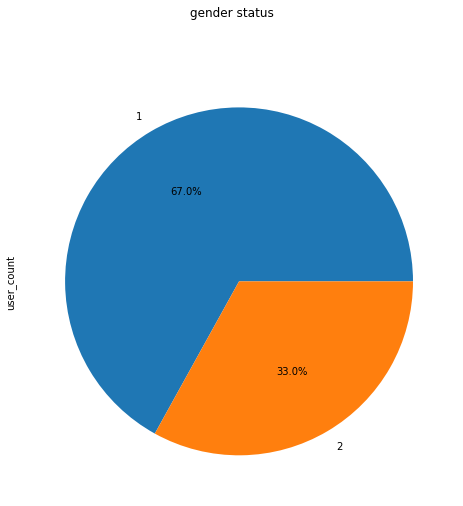

In [137]:
userstatus = user.groupby(['gender']).count().rename(columns={'user_id':'user_count'})
userstatus['user_count'].plot.pie(subplots=True,figsize=(8, 8),title="gender status",autopct='%1.1f%%')

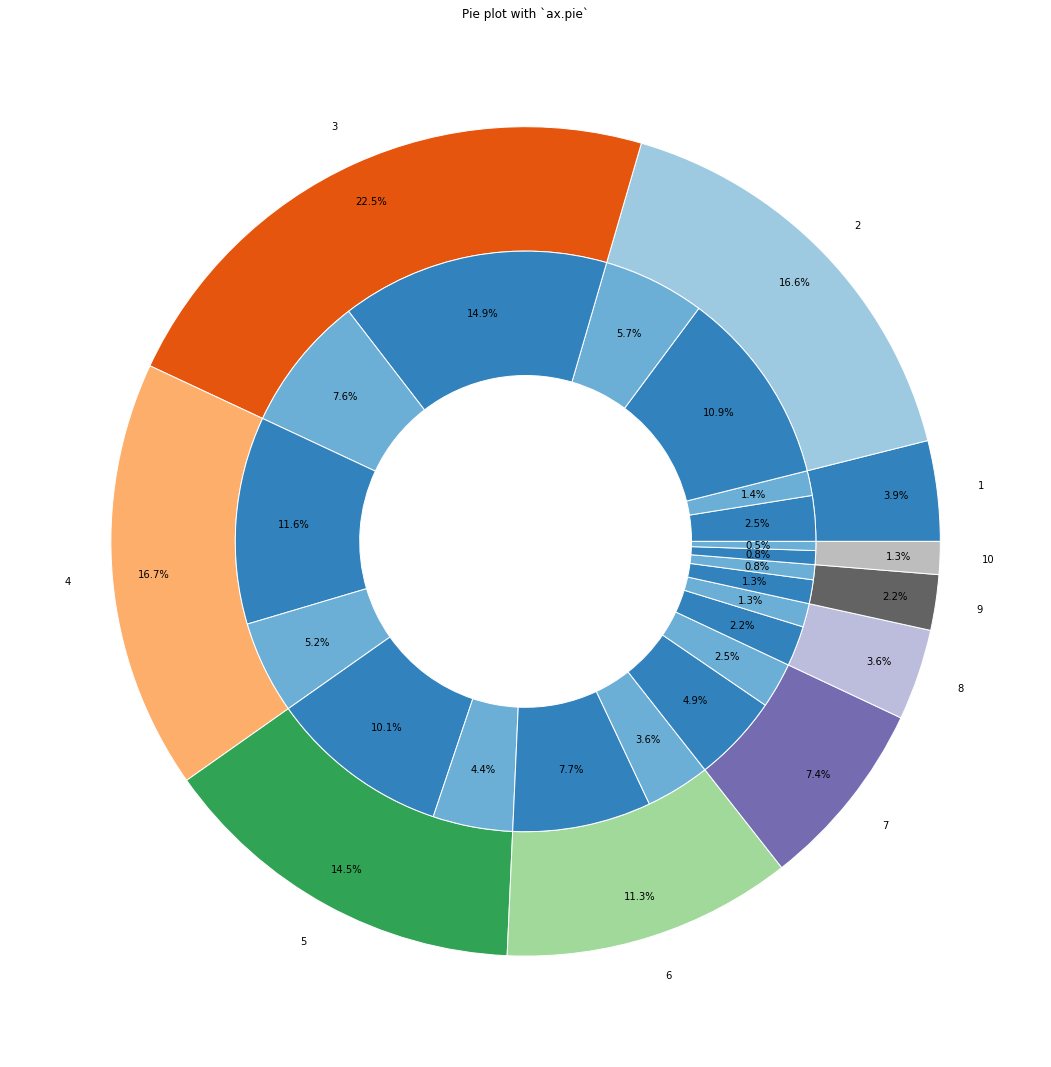

In [136]:
df = user.groupby(['age','gender']).count()
vals = df.values.reshape([10,2])
vals = vals/vals.sum()*100

import numpy as np

fig = plt.figure(figsize=(16,16))
ax = fig.add_axes((0.1,0.1,0.9,0.9))

cmap = plt.get_cmap("tab20c")

outer_colors = cmap(np.arange(10)*2)
inner_colors = cmap(np.arange(20)%2)

ax.pie(vals.sum(axis=1), radius=1, colors=outer_colors,autopct='%1.1f%%',labels = range(1,11),pctdistance=0.9,
       wedgeprops=dict(width=size, edgecolor='w'))

ax.pie(vals.flatten(), radius=0.7, colors=inner_colors,autopct='%1.1f%%',pctdistance=0.8,
       wedgeprops=dict(width=size, edgecolor='w'))

ax.set(aspect="equal", title='pie view')
ax.set_axis_off()
plt.show()

用户偏差分析:
- 年龄段`2,3,4,5,6`占主体
- 男女比例`2:1`

### 广告统计分析

> ad.csv

- user_id: 从 1 到 N 随机编号生成的不重复的加密的用户 id，其中 N 为用户总数目（训练集和测试集）。
- creative_id: 用户点击的广告素材的 id，采用类似于 user_id 的方式生成。
- ad_id: 该素材所归属的广告的 id，采用类似于 user_id 的方式生成。每个广告可能包含多个可展示的素材。
- product_id: 该广告中所宣传的产品的 id，采用类似于 user_id 的方式生成。
- product_category: 该广告中所宣传的产品的类别 id，采用类似于 user_id 的方式生成。
- advertiser_id: 广告主的 id，采用类似于 user_id 的方式生成。
- industry: 广告主所属行业的 id，采用类似于 user_id 的方式生成。

有几个实体:
- 广告素材
- 广告
- 产品
- 制造商

In [295]:
ad.replace('\\N',np.nan).to_numeric()

AttributeError: 'DataFrame' object has no attribute 'to_numeric'

In [296]:
ad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2481135 entries, 0 to 2481134
Data columns (total 6 columns):
creative_id         int64
ad_id               int64
product_id          object
product_category    int64
advertiser_id       int64
industry            object
dtypes: int64(4), object(2)
memory usage: 113.6+ MB


In [287]:
# 检查空值情况
from numpy import nan

for col in ad.columns:    
#     print(col,'\\N' in ad[col].values)
    col_freq = freq_count(ad[col])
    print(col,col_freq.shape)
    print(col_freq)
    print("-------------------------")

creative_id (2481135, 2)
[[      1       1]
 [      4       1]
 [      7       1]
 ...
 [4445716       1]
 [4445717       1]
 [4445718       1]]
-------------------------
ad_id (2264190, 2)
[[      1       1]
 [      4       1]
 [      7       1]
 ...
 [3812198       1]
 [3812199       1]
 [3812200       1]]
-------------------------
product_id (33273, 2)
[['1' 1]
 ['10' 1]
 ['100' 82]
 ...
 ['9998' 2]
 ['9999' 3]
 ['\\N' 929524]]
-------------------------
product_category (18, 2)
[[     1    259]
 [     2 923994]
 [     3 283817]
 [     4  22917]
 [     5 227970]
 [     6  12077]
 [     7   7611]
 [     8 233832]
 [     9   2970]
 [    10     18]
 [    11   1379]
 [    12  19592]
 [    13  38072]
 [    14     95]
 [    15    332]
 [    16   7216]
 [    17  35638]
 [    18 663346]]
-------------------------
advertiser_id (52090, 2)
[[    2    11]
 [    3    35]
 [    4     2]
 ...
 [62962     7]
 [62964    11]
 [62965    26]]
-------------------------
industry (326, 2)
[['1' 35]
 ['10'

In [282]:
freq_count(ad['product_id'])

(33273, 2)

ad 表中的属性空值情况如下:
- creative_id 无空值
- ad_id 无空值
- product_id 存在空值
- product_category 无空值
- advertiser_id 无空值
- industry 存在空值

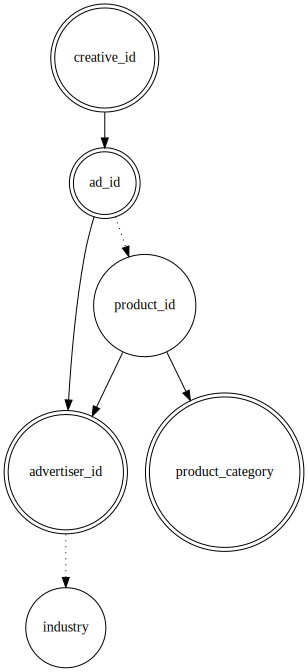

In [202]:
# ad属性之间的主观逻辑关系
from graphviz import Digraph
dot = Digraph()
dot.node('A', 'creative_id', shape='doublecircle')
dot.node('B', 'ad_id', shape='doublecircle')
dot.node('C', 'product_id', shape='circle')
dot.node('D', 'advertiser_id', shape='doublecircle')
dot.node('E', 'product_category', shape='doublecircle')
dot.node('F', 'industry', shape='circle')
dot.edges(['AB','CD','CE'])
dot.edge('B', 'C', style='dotted')
dot.edge('B', 'D')
# dot.edge('B', 'E')
dot.edge('D', 'F', style='dotted')
dot

In [274]:
"""
一个二层统计:
- 首先获取了 col 的频率
- 然后计算了 col 的频率的频率

"""
def col_count_freq(col):
    cntlist = ad.groupby([col])[col].count().values
    ans = freq_count(cntlist)
    print(ans)
    return ans

In [277]:
col_count_freq('creative_id').shape

[[      1 2481135]]


(1, 2)

creative_id 中的每一个条目仅出现一次

从某种意义上来说,这是可以表示索引

In [278]:
col_count_freq('ad_id').shape

[[      1 2094478]
 [      2  140120]
 [      3   19732]
 [      4    5975]
 [      5    2093]
 [      6     888]
 [      7     427]
 [      8     201]
 [      9     107]
 [     10      69]
 [     11      33]
 [     12      26]
 [     13       8]
 [     14      14]
 [     15       8]
 [     16       7]
 [     17       2]
 [     18       1]
 [     19       1]]


(19, 2)

ad_id 表示广告的id,从结果看,99%的广告只出现一次,这表示大部分的广告只有一个广告素材

一个广告最多可以包含19个广告素材

In [279]:
col_count_freq('advertiser_id').shape

[[    1 12675]
 [    2  6500]
 [    3  3906]
 ...
 [18915     1]
 [24500     1]
 [26906     1]]


(1095, 2)

advertiser_id 表示投广告客户

从结果看,一个客户最多在腾讯投过 26906 个广告素材,这是腾讯自己吧..

大部分客户只在腾讯投过一次广告素材


In [280]:
col_count_freq('product_category').shape 

[[    18      1]
 [    95      1]
 [   259      1]
 [   332      1]
 [  1379      1]
 [  2970      1]
 [  7216      1]
 [  7611      1]
 [ 12077      1]
 [ 19592      1]
 [ 22917      1]
 [ 35638      1]
 [ 38072      1]
 [227970      1]
 [233832      1]
 [283817      1]
 [663346      1]
 [923994      1]]


(18, 2)

product_category 产品类目应该不会有很多

### ad属性间的相关性分析

In [297]:
ad.corr()

,creative_id,ad_id,product_category,advertiser_id
creative_id,1.000000,0.997678,-0.041031,0.270326
ad_id,0.997678,1.000000,-0.043707,0.272517
product_category,-0.041031,-0.043707,1.000000,-0.071983
advertiser_id,0.270326,0.272517,-0.071983,1.000000
